# Stroke Risk Classification with Explainable Machine Learning

## Project Overview

This project investigates machine learning approaches for classifying
stroke risk using demographic, lifestyle, and health-related features.

The dataset presents a significant class-imbalance challenge, with stroke
cases representing only a small proportion of the observations. Therefore,
model performance is evaluated using metrics beyond accuracy, including
precision, recall, F1-score, ROC-AUC, and PR-AUC.

### Objectives

- Perform exploratory data analysis and identify data-quality issues
- Build a leakage-safe preprocessing pipeline
- Compare multiple machine learning classification models
- Evaluate model performance using stratified cross-validation
- Investigate the effect of classification thresholds
- Analyze model predictions using explainability techniques
- Identify common sources of false-positive and false-negative predictions

### Important Note

This project is an educational machine learning study and is **not a
clinical diagnostic system**. The results should not be used for medical
decision-making.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

# **1. Dataset Overview**

## 1.1 Loading the Dataset

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

print(f"Dataset shape: {df.shape}")
display(df.sample(10))

Dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
573,58007,Female,36.0,0,0,Yes,Private,Urban,87.88,34.7,smokes,0
2000,44391,Male,54.0,0,0,Yes,Private,Urban,65.69,21.4,never smoked,0
4455,53821,Male,18.0,0,0,No,Private,Rural,100.47,31.9,never smoked,0
2800,8655,Female,51.0,0,1,Yes,Self-employed,Urban,100.96,33.4,never smoked,0
3594,41122,Female,62.0,0,0,Yes,Private,Rural,226.38,47.4,never smoked,0
2278,65632,Male,42.0,0,0,Yes,Private,Rural,145.50,31.8,formerly smoked,0
223,54724,Female,81.0,0,0,No,Govt_job,Urban,70.30,25.8,smokes,1
4808,58495,Male,34.0,0,0,Yes,Private,Rural,84.08,32.9,never smoked,0
3724,64189,Male,61.0,0,0,Yes,Self-employed,Rural,152.84,28.6,Unknown,0
629,46218,Female,51.0,0,0,Yes,Self-employed,Urban,111.15,34.1,smokes,0


## 1.2 Dataset Structure

In [3]:
print(f"Number of observations: {df.shape[0]:,}")
print(f"Number of features: {df.shape[1]:,}")

display(df.dtypes.to_frame("Data Type"))

Number of observations: 5,110
Number of features: 12


,Data Type
id,int64
gender,object
age,float64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


### Feature Description

| Feature | Description |
|---|---|
| `age` | Age of the individual |
| `hypertension` | Whether the individual has hypertension |
| `heart_disease` | Whether the individual has heart disease |
| `avg_glucose_level` | Average glucose level |
| `bmi` | Body mass index |
| `smoking_status` | Smoking category |
| `stroke` | Target variable indicating stroke occurrence |

##1.3 Statistical Summary

In [4]:
#Only numerical data
df[['age', 'avg_glucose_level', 'bmi']].describe()

,age,avg_glucose_level,bmi
count,5110.000000,5110.000000,4909.000000
mean,43.226614,106.147677,28.893237
std,22.612647,45.283560,7.854067
min,0.080000,55.120000,10.300000
25%,25.000000,77.245000,23.500000
50%,45.000000,91.885000,28.100000
75%,61.000000,114.090000,33.100000
max,82.000000,271.740000,97.600000


## 1.4 Missing Value Analysis

The dataset contains missing values only in the `bmi` feature. Rather than
removing these observations, missing BMI values will be imputed using the
median during model preprocessing.

The imputation step will be included inside the preprocessing pipeline so
that information from the validation/test data does not influence the
training process.

In [5]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]

display(missing_values.to_frame("Missing Values"))

,Missing Values
bmi,201


##1.5 Duplicate Value Analysis

In [6]:
summary = pd.DataFrame({
    "Metric": ["Duplicate IDs", "Fully Duplicate Rows"],
    "Count": [df['id'].duplicated().sum(), df.duplicated().sum()]
})

display(summary)

,Metric,Count
0,Duplicate IDs,0
1,Fully Duplicate Rows,0


## 1.6 Categorical Feature Analysis

Categorical variables were inspected to identify their unique categories
and detect potential data-quality issues.

In [7]:
categorical_columns = ['gender','ever_married','work_type','Residence_type','smoking_status']
print("Number of categorical columns:",len(categorical_columns))

for col in categorical_columns:
    print(col)
    print(df[col].unique())
    print()

Number of categorical columns: 5
gender
['Male' 'Female' 'Other']

ever_married
['Yes' 'No']

work_type
['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']

Residence_type
['Urban' 'Rural']

smoking_status
['formerly smoked' 'never smoked' 'smokes' 'Unknown']



## 1.7 Target Distribution

The target variable is highly imbalanced. Because stroke cases represent
only a small fraction of the dataset, accuracy alone may provide a
misleading assessment of model performance.

Therefore, recall, precision, F1-score, ROC-AUC, and PR-AUC will be used
alongside accuracy.

In [8]:
target_counts = df["stroke"].value_counts()

display(
    target_counts.rename(index={
        0: "No Stroke",
        1: "Stroke"
    }).to_frame("Count")
)

,Count
stroke,
No Stroke,4861
Stroke,249


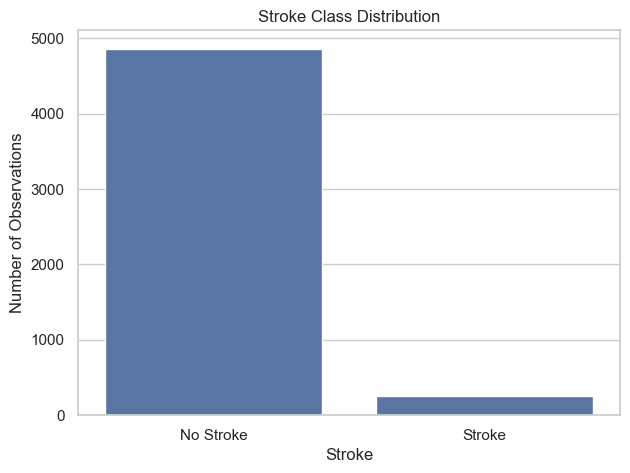

In [9]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="stroke"
)

plt.title("Stroke Class Distribution")
plt.xlabel("Stroke")
plt.ylabel("Number of Observations")
plt.xticks([0, 1], ["No Stroke", "Stroke"])

plt.show()

In [10]:
class_percentage = (
    df["stroke"].value_counts(normalize=True).mul(100).rename(index={0: "No Stroke", 1: "Stroke"}))

display(
    class_percentage.to_frame("Percentage")
)

,Percentage
stroke,
No Stroke,95.127202
Stroke,4.872798


## 1.8 Data Quality Summary

In [11]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Duplicate rows",
        "Duplicate IDs",
        "Missing BMI values"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        df["id"].duplicated().sum(),
        df["bmi"].isnull().sum()
    ]
})

display(quality_summary)

,Metric,Value
0,Number of rows,5110
1,Number of columns,12
2,Duplicate rows,0
3,Duplicate IDs,0
4,Missing BMI values,201


##**2 Analysing the numerical variables**
Age-Values are fairly spread <br> <br>
Avg glucose level-We can see values are concentrated at around 60-120 & some values can be seen in the higher end can be potential outliers (Right skewed) <br> <br>
BMI-We can see values are concentrated at around 20-35 and some unusally high values can be potential outliers (Right skewed)

In [12]:
numerical_columns = ['age','avg_glucose_level','bmi']

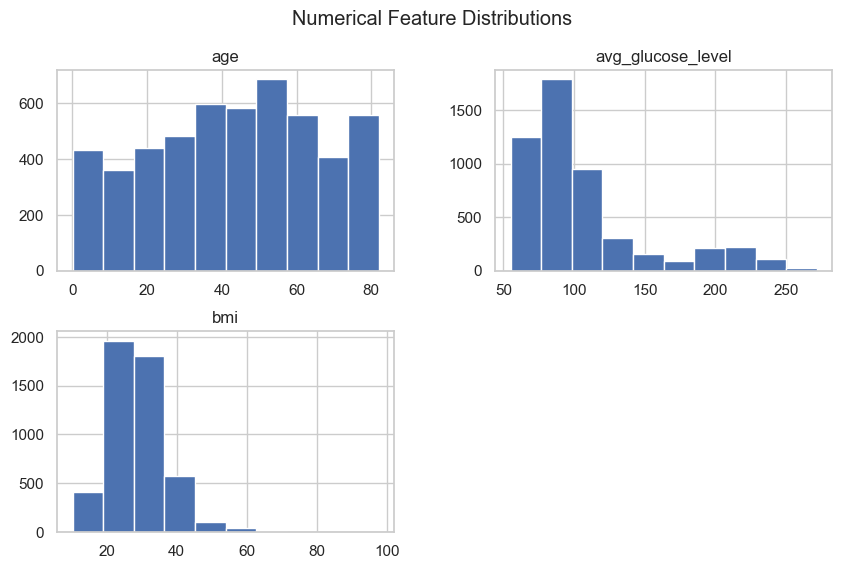

In [13]:
df[numerical_columns].hist(figsize=(10, 6))
plt.suptitle("Numerical Feature Distributions")
plt.show()

##2.1 Checking Skewness
📐 What is Skewness? Skewness measures the asymmetry of the distribution of a dataset.

Skewness = 0 → Perfectly symmetrical (e.g., normal distribution)

Skewness < 0 → Left-skewed (long tail on the left)

Skewness > 0 → Right-skewed (long tail on the right)

It helps you understand how balanced your data is and whether transformations are needed.

📊 Interpretation of Skewness Values:

Skewness Value Interpretation

~ 0 Symmetrical (normal-ish)

0 to ±0.5 Fairly symmetrical

±0.5 to ±1 Moderately skewed

greater than ±1 Highly skewed

In [14]:
df[numerical_columns].skew()

age                 -0.137059
avg_glucose_level    1.572284
bmi                  1.055340
dtype: float64

##2.2 Checking outliers
Only for numerical data <br>
Can see some potential outliers in avg_glucose_level and bmi

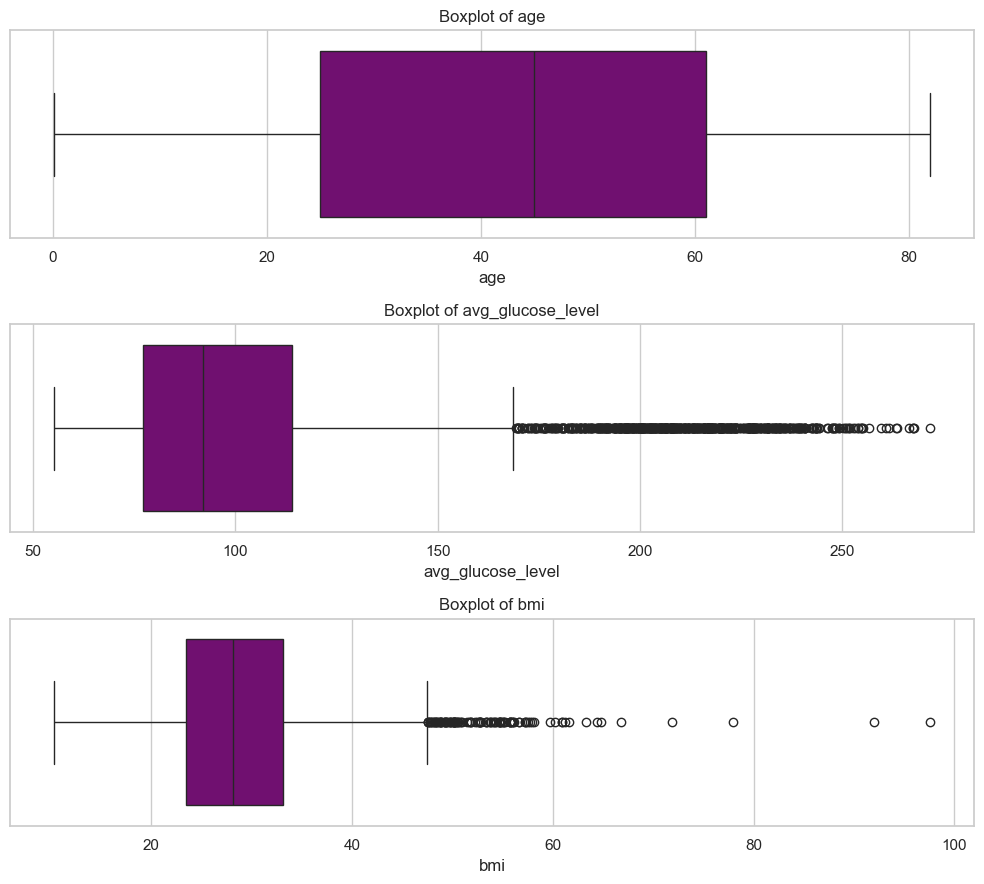

In [15]:
plt.figure(figsize=(10, 9))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns), 1, i)
    sns.boxplot(x=df[col], color='purple')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()

plt.show()

##**3 Analysing categorical variables**

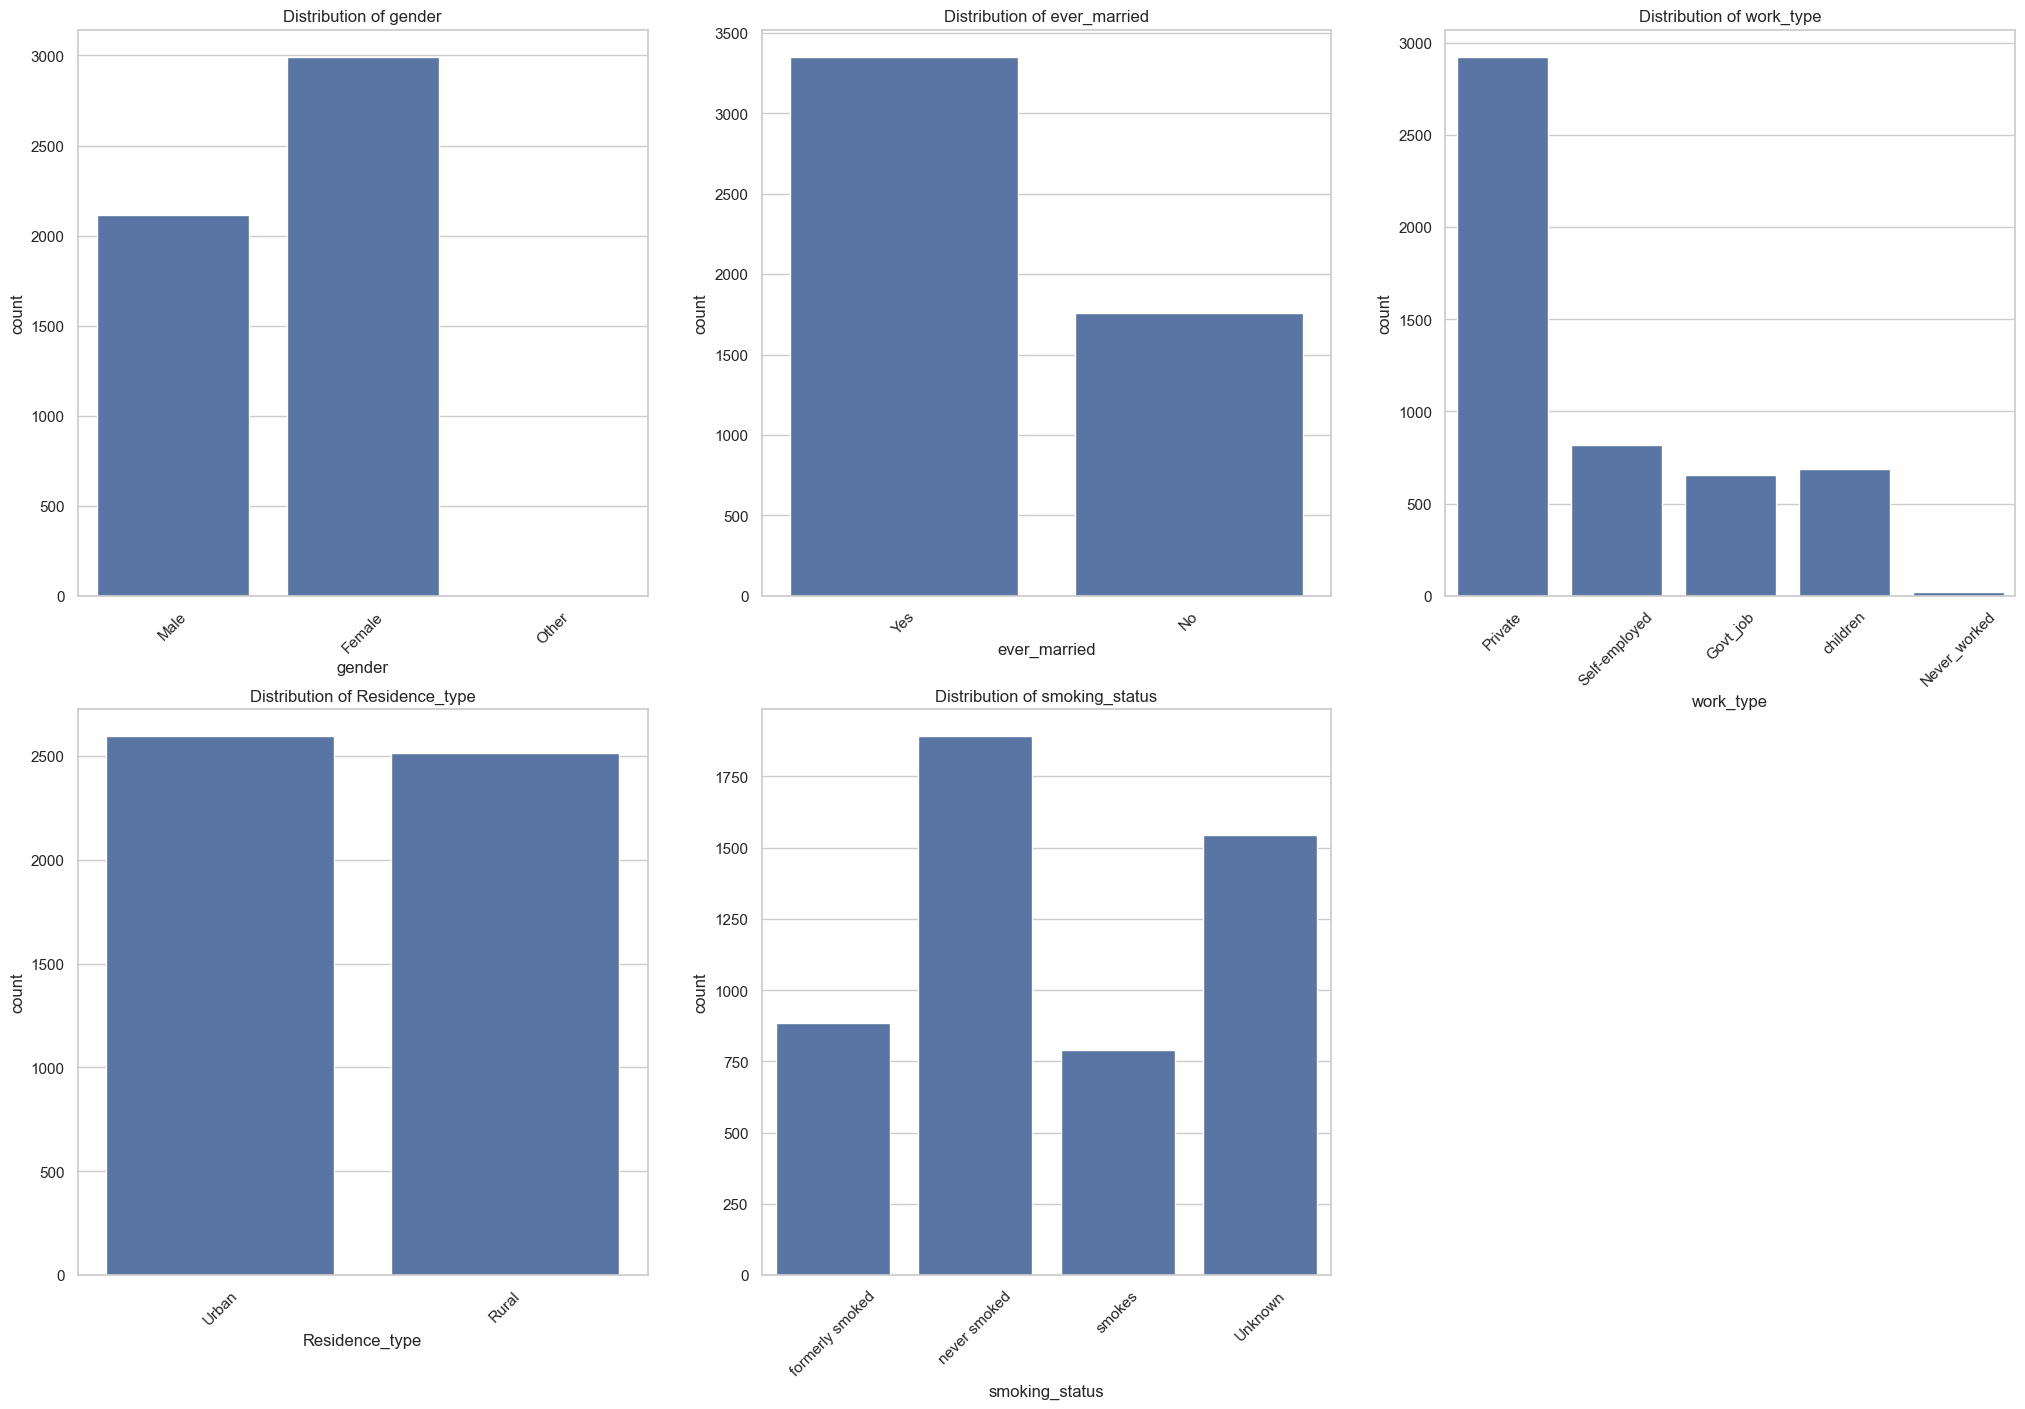

In [16]:
plt.figure(figsize=(25, 25))

for i in range(len(categorical_columns)):
    plt.subplot(3, 3, i + 1)

    sns.countplot(data=df, x=categorical_columns[i])

    plt.title(f"Distribution of {categorical_columns[i]}")
    plt.xticks(rotation=45)

##3.1 Corelation Analysis

##a. Pearson Correlation

No redundant columns found to drop

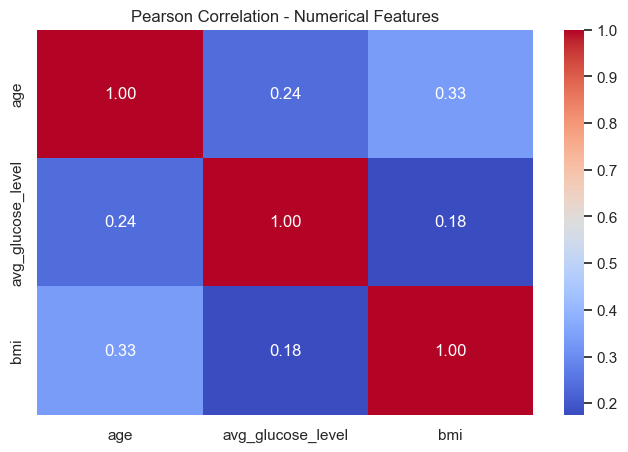

In [17]:
correlation_matrix = df[numerical_columns].corr(method='pearson')

plt.figure(figsize=(8, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Pearson Correlation - Numerical Features")
plt.show()

##b. Point-Biserial Correlation

p < 0.05 → statistically significant<br>
p >= 0.05 → not statistically significant



Age                → stronger association + significant<br>
Avg glucose        → weak association + significant<br>
BMI                → extremely weak association + significant<br>

Occurs betn numerical_feature vs categorical

In [18]:
from scipy.stats import pointbiserialr

for col in ['age', 'avg_glucose_level', 'bmi']:
    temp = df[[col, 'stroke']].dropna()

    correlation, p_value = pointbiserialr(temp[col], temp['stroke'])

    print(f"{col}:")
    print(f"Correlation = {correlation:.6f}")
    print(f"P-value = {p_value:.6e}")
    print()

age:
Correlation = 0.245257
P-value = 7.030778e-71

avg_glucose_level:
Correlation = 0.131945
P-value = 2.767811e-21

bmi:
Correlation = 0.042374
P-value = 2.983269e-03



##c. Cramer V

Higher Value means String association with stroke <br>
Value close to 0 means little or no association with stroke

In [19]:
from scipy.stats import chi2_contingency
import numpy as np

categorical_columns = [
    'gender',
    'hypertension',
    'heart_disease',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]

    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    phi2_corrected = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    r_corrected = r - ((r - 1) ** 2) / (n - 1)
    k_corrected = k - ((k - 1) ** 2) / (n - 1)

    return np.sqrt(
        phi2_corrected /
        min(k_corrected - 1, r_corrected - 1)
    )

cramers_results = []

for col in categorical_columns:
    value = cramers_v(df[col], df['stroke'])
    cramers_results.append([col, value])

cramers_df = pd.DataFrame(
    cramers_results,
    columns=['Feature', "Cramer's V"]
)

print(cramers_df)

          Feature  Cramer's V
0          gender    0.000000
1    hypertension    0.125607
2   heart_disease    0.132178
3    ever_married    0.106478
4       work_type    0.094020
5  Residence_type    0.003993
6  smoking_status    0.071539


##3.2 Density Plot

Age<br>
* Your dataset contains people across a wide range of ages.
* There are fewer observations at very young and very old ages.
* Most observations are concentrated around middle/older adulthood.

Glucose<br>
* Most people have glucose levels around the lower range.
* There are some people with substantially higher glucose levels.
* The distribution is right-skewed.
* The second bump suggests the distribution may be multimodal.

BMI<br>
* Most observations have BMI around the 25–35 region.
* There are fewer observations with very high BMI.
* The distribution has a right tail. Therefore, BMI is right-skewed.

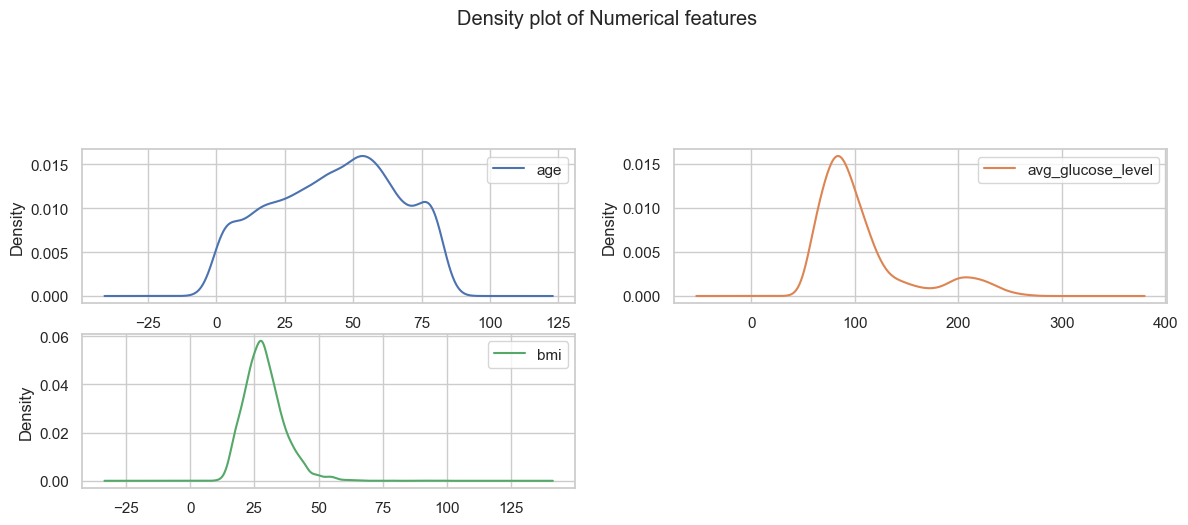

In [20]:
df[numerical_columns].plot(kind='density',figsize=(14,14),subplots=True,layout=(6,2),title="Density plot of Numerical features",sharex=False)
plt.show()

## **4 Data Pre-processing**

##4.1 Dropping unnecessary ID column

In [21]:
df=df.drop('id', axis=1)

##4.2 Removing 'other' gender

The gender variable contained only one observation (0.0196%) in the Other category. Due to its extremely low representation, this category was removed before modeling to avoid an unreliable minority category also it would create an unnecessary 'other' column when we do one-hot encoding. Creating another column for such a low represented data is unreliable.

In [22]:
print(df['gender'].value_counts())
print(df['gender'].value_counts(normalize=True) * 100)

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
gender
Female    58.590998
Male      41.389432
Other      0.019569
Name: proportion, dtype: float64


In [23]:
df = df.drop(df[df['gender'] == 'Other'].index)
print(df['gender'].value_counts())

gender
Female    2994
Male      2115
Name: count, dtype: int64


## 4.3 Train-Test Split

The dataset was split into a training set (80%) and a testing set (20%). Stratified splitting was used because the target variable is highly imbalanced (only 4.87% stroke cases). Stratification keeps the same stroke ratio in both sets, otherwise the test set could end up with very few or no stroke cases.

In [24]:
X = df.drop('stroke', axis=1)
y = df['stroke']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


print("\nStroke count in training set:", y_train.sum())
print("Stroke count in test set:", y_test.sum())

Training set: (4087, 10)
Test set: (1022, 10)

Stroke count in training set: 199
Stroke count in test set: 50


## 4.4 Pre-processing Pipeline


In [25]:
numerical_features = ["age","avg_glucose_level","bmi"]
ordinal_features = ["ever_married","gender"]
binary_features = ["hypertension","heart_disease"]
nominal_features = ["work_type","Residence_type","smoking_status"]

In [26]:
class IQRCapper(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)

        q1 = np.nanpercentile(X, 25, axis=0)
        q3 = np.nanpercentile(X, 75, axis=0)

        iqr = q3 - q1

        self.lower = q1 - 1.5 * iqr
        self.upper = q3 + 1.5 * iqr

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)

        return np.clip(
            X,
            self.lower,
            self.upper
        )

Simple Imputing:
BMI had rightly skewed value or graph. As a result if I imputed using mean then the values would pull the distribution toward the right. Median was the safest choice here

Capping outliers: Capped the outliers to upper limit & lower limit

Ordinal Encoding: For having binary categories

One Hot Encoding: For having multivariate categories

In [27]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("capper", IQRCapper()),
    ("scaler", StandardScaler())
])

ordinal_pipeline = Pipeline([
    ("encoder", OrdinalEncoder())
])

nominal_pipeline = Pipeline([
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

##4.5 Column Transformer

In [28]:
preprocessor = ColumnTransformer([

    ("numeric", numeric_pipeline, numerical_features),

    ("binary", "passthrough", binary_features),

    ("ordinal", ordinal_pipeline, ordinal_features),

    ("nominal", nominal_pipeline, nominal_features)
])

## **5 Model Training & Testing**

In [29]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=500,
        random_state=RANDOM_STATE
    )
}

In [30]:
pipelines = {}

for name, model in models.items():

    pipelines[name] = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

In [31]:
for name, pipeline in pipelines.items():

    pipeline.fit(X_train, y_train)

    print(f"{name} trained successfully.")

Logistic Regression trained successfully.
Decision Tree trained successfully.
KNN trained successfully.
Neural Network trained successfully.


# **6 Model Evaluation**

##6.1 K-Fold Cross Validation

The 80/20 hold-out gives only one estimate, which depends on which rows happened to land in the test set. With only 249 stroke cases in the whole dataset, a single split can be misleading. 5-Fold Cross Validation repeats the training and testing five times, each time holding out a different fifth of the data, so every row is tested exactly once. The average across folds is a more reliable estimate, and the standard deviation shows how much the result moves from fold to fold.

Scaling is done separately inside each fold, using only that fold's training rows, so no information from the held-out rows leaks into the scaler.

In [32]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [33]:
cv_results = []

for name, pipeline in pipelines.items():

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean(),
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

display(
    cv_results_df.round(3)
)

/Users/tahsinhossain/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tahsinhossain/Library/Python/3.9/lib/python/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/tahsinhossain/Library/Python/3.9/lib/python/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.743,0.138,0.819,0.237,0.838,0.193
1,Decision Tree,0.715,0.115,0.724,0.198,0.764,0.139
2,KNN,0.949,0.033,0.005,0.009,0.632,0.079
3,Neural Network,0.923,0.099,0.070,0.081,0.746,0.109


## 6.2 Test set evaluation

In [34]:
test_results = []

for name, pipeline in pipelines.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    test_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test, y_prob
        ),
        "PR-AUC": average_precision_score(
            y_test, y_prob
        )
    })

test_results_df = pd.DataFrame(test_results)

display(
    test_results_df.round(3)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.734,0.132,0.80,0.227,0.840,0.268
1,Decision Tree,0.736,0.131,0.78,0.224,0.795,0.168
2,KNN,0.950,0.400,0.04,0.073,0.604,0.085
3,Neural Network,0.938,0.217,0.10,0.137,0.743,0.142


##6.3 Accuracy comparison

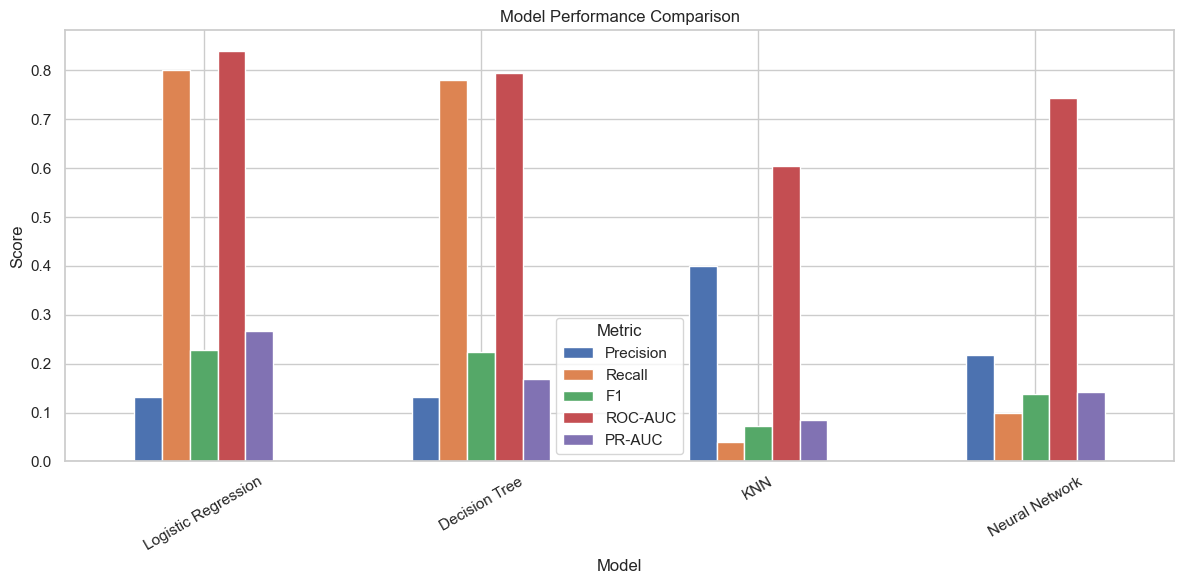

In [35]:
metrics = [
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

plot_df = test_results_df.set_index("Model")[metrics]

plot_df.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=30)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

##6.4 Confusion Matrix

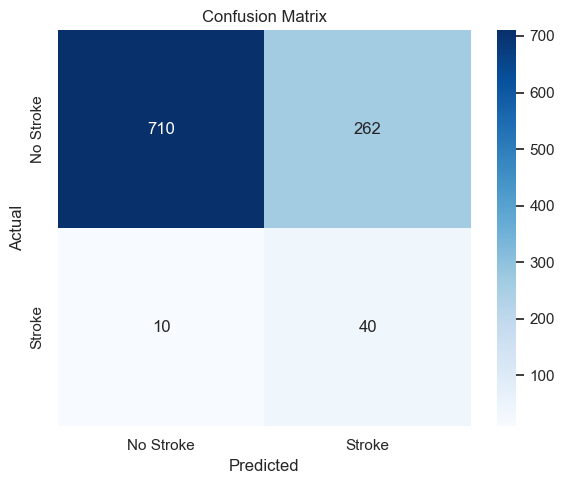

In [36]:
final_model = pipelines["Logistic Regression"]

y_pred = final_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Stroke", "Stroke"],
    yticklabels=["No Stroke", "Stroke"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

##6.5 PR Curve

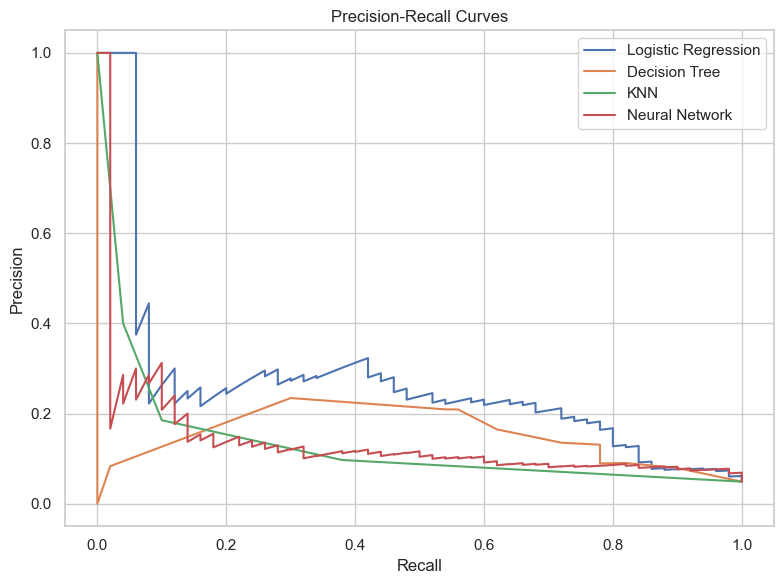

In [37]:
plt.figure(figsize=(8, 6))

for name, pipeline in pipelines.items():

    y_prob = pipeline.predict_proba(X_test)[:, 1]

    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    plt.plot(
        recall,
        precision,
        label=name
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.tight_layout()
plt.show()

##6.6 ROC-AUC Comparison

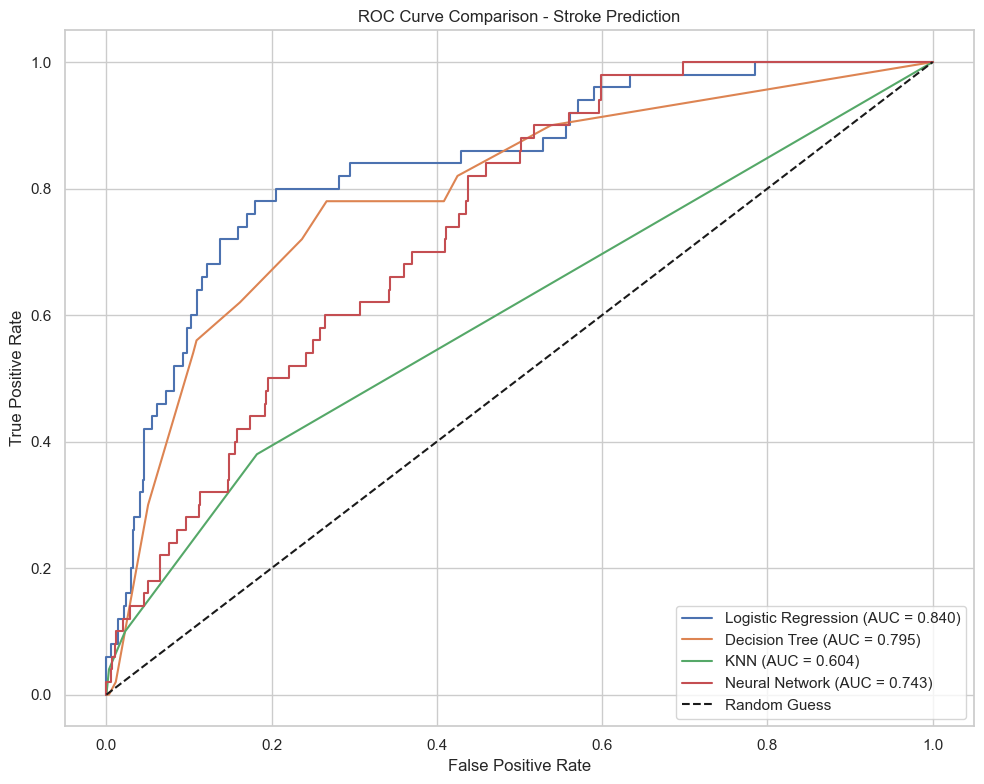

In [38]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Your trained pipelines
models = {
    "Logistic Regression": pipelines["Logistic Regression"],
    "Decision Tree": pipelines["Decision Tree"],
    "KNN": pipelines["KNN"],
    "Neural Network": pipelines["Neural Network"]
}

plt.figure(figsize=(10, 8))

for name, model in models.items():

    # Predict probabilities for the positive class (stroke = 1)
    y_probs = model.predict_proba(X_test)[:, 1]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_probs)

    # Calculate AUC
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random-guess baseline
plt.plot(
    [0, 1],
    [0, 1],
    "k--",
    label="Random Guess"
)

# Formatting
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Stroke Prediction")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


# **7. Conclusions**

This project investigated machine learning approaches for stroke-risk
classification using an imbalanced healthcare dataset.

The analysis demonstrated that accuracy alone is insufficient for evaluating
the models because the positive class represents a relatively small portion
of the dataset.

Multiple classification algorithms were compared using stratified
cross-validation and an independent test set. Performance was evaluated
using precision, recall, F1-score, ROC-AUC, and PR-AUC.

Threshold analysis was also performed to examine the trade-off between
precision and recall.

## Limitations

- The dataset is relatively small and highly imbalanced.
- The dataset may not represent the broader population.
- Model performance has not been externally validated.
- The results should not be interpreted as clinical evidence.
- The application is intended for educational and research purposes only.

In [40]:
import joblib

joblib.dump(final_model, "models/stroke_pipeline.pkl")

['models/stroke_pipeline.pkl']